In [1]:
!pip install -q anthropic tiktoken


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os, time
import pandas as pd
import tiktoken

import anthropic
HAVE_KEY = bool(os.environ.get("ANTHROPIC_API_KEY"))
client = anthropic.Anthropic() if HAVE_KEY else None
print("Anthropic key detected:", HAVE_KEY)

enc = tiktoken.get_encoding("o200k_base")  # GPT-4o/4.1/5-family tokenizer
def gpt_tokens(text: str) -> int:
    return len(enc.encode(text))

Anthropic key detected: True


# Tokens, not words: what your writing actually costs an AI to read

Most of what you write is increasingly read by machines, not people\. In my last role, analytics showed ~60% of our docs traffic was automated\. Our silent second readers were LLM crawlers and agents, not humans\. Those readers don't count words\. They count tokens, and tokens cost money and time\.

So here's a question most writers never ask: what does my writing cost an AI to read?

This notebook answers it with real measurements\. Everything here is computed live; nothing is hardcoded\.

## Tokens ≠ words

A token is a chunk of text a model processes\. English prose runs a bit over one token per word; tables, code, and JSON run higher because the model pays for every bracket, pipe, and quote\.

One caveat: every model family tokenizes differently\. We use tiktoken \(the GPT\-family tokenizer\) to see the concept, then get Claude's exact counts from Anthropic's API\. That is because tiktoken does not match Claude\.

In [5]:
prose = (
    "Our warehouse in Berlin shipped 1,240 orders last week, up 8 percent from the "
    "week before. Returns held steady at about 3 percent. The team is on track to hit "
    "the quarterly target if volume stays flat."
)

markdown_table = """| Metric | Value | Change |
| --- | --- | --- |
| Orders shipped | 1,240 | +8% |
| Returns | ~3% | flat |
| On track for target | Yes | — |"""

json_blob = (
    '{"warehouse": "Berlin", "orders_shipped": 1240, "wow_change_pct": 8, '
    '"returns_pct": 3, "on_track": true}'
)

code_snippet = (
    "df = orders[orders.week == 'last']\n"
    "shipped = df.shape[0]            # 1240\n"
    "wow = (shipped / prev - 1) * 100 # +8%\n"
    "assert returns_rate < 0.05, 'returns spiked'"
)

samples = {"prose": prose, "markdown_table": markdown_table,
           "json": json_blob, "code": code_snippet}

In [7]:
rows = []
for name, text in samples.items():
    words = len(text.split())
    toks = gpt_tokens(text)
    rows.append({"doc_type": name, "chars": len(text), "words": words,
                 "gpt_tokens": toks, "tokens_per_word": round(toks / words, 2)})
df = pd.DataFrame(rows)
df

,doc_type,chars,words,gpt_tokens,tokens_per_word
0,prose,201,37,46,1.24
1,markdown_table,139,39,46,1.18
2,json,104,10,36,3.60
3,code,158,27,56,2.07


Same facts, four formats, and the token bill swings widely\. Prose is close to one token per word; the table, JSON, and code cost far more per word because structure isn't free\. Clean prose is cheap; every decorative structure is billed on every read\.

In [9]:
if '_dntk' in globals():
  _dntk.dataframe_utils.configure_dataframe_formatter('{}')
else:
  _deepnote_current_table_attrs = '{}'

by_type = _dntk.execute_sql(
  'SELECT doc_type,\n       words,\n       gpt_tokens,\n       ROUND(gpt_tokens * 1.0 / words, 2) AS tokens_per_word\nFROM df\nORDER BY tokens_per_word DESC',
  'SQL_DEEPNOTE_DATAFRAME_SQL',
  audit_sql_comment='',
  sql_cache_mode='cache_disabled',
  return_variable_type='dataframe'
)
by_type

,doc_type,words,gpt_tokens,tokens_per_word
0,json,10,36,3.60
1,code,27,56,2.07
2,prose,37,46,1.24
3,markdown_table,39,46,1.18


## Words are free\. Tokens are not\.

Now the part tiktoken can't tell us: what Claude actually sees, and what it costs\. Claude's tokenizer is different, so we ask Anthropic's token\-counting API for the exact count, then price it against the current Claude tiers\.

In [11]:
# Anthropic list price, as of 2026-06-24 — verify at anthropic.com/pricing before publishing.
PRICING = pd.DataFrame([
    {"model": "claude-haiku-4-5", "in_per_1m": 1.00, "out_per_1m": 5.00},
    {"model": "claude-sonnet-5",  "in_per_1m": 2.00, "out_per_1m": 10.00},
    {"model": "claude-opus-5",    "in_per_1m": 5.00, "out_per_1m": 25.00},
])

def claude_input_tokens(text: str, model: str = "claude-opus-5") -> int:
    r = client.messages.count_tokens(model=model, messages=[{"role": "user", "content": text}])
    return r.input_tokens

if HAVE_KEY:
    doc = prose
    claude_toks = claude_input_tokens(doc)
    gpt_toks = gpt_tokens(doc)
    print(f"Same text — GPT tokenizer: {gpt_toks} tokens | Claude (exact): {claude_toks} tokens")
    scale = 10_000 / len(doc.split())
    est_tokens = claude_toks * scale
    cost = PRICING.assign(input_cost_usd=lambda d: (est_tokens / 1_000_000) * d.in_per_1m)
    display(cost[["model", "in_per_1m", "input_cost_usd"]])
else:
    print("No API key — skipping exact Claude counts.")

Same text — GPT tokenizer: 46 tokens | Claude (exact): 77 tokens


,model,in_per_1m,input_cost_usd
0,claude-haiku-4-5,1.0,0.020811
1,claude-sonnet-5,2.0,0.041622
2,claude-opus-5,5.0,0.104054


Two takeaways: the two tokenizers disagree on the same text \(so never price one model with another's counts\), and even at list price, reading is cheap\. The real money is in what the model writes back, and which model you pick\. Let's measure that\.

In [13]:
MODELS = ["claude-haiku-4-5", "claude-sonnet-5", "claude-opus-5"]
task = (f"Summarize this update in exactly two bullet points for an executive:\n\n{prose}")

def price_row(model):
    return PRICING.set_index("model").loc[model]

results = []
if HAVE_KEY:
    for m in MODELS:
        t0 = time.perf_counter()
        resp = client.messages.create(
            model=m, max_tokens=300,
            messages=[{"role": "user", "content": task}],
        )
        secs = time.perf_counter() - t0
        text = "".join(b.text for b in resp.content if b.type == "text")
        p = price_row(m)
        cost = (resp.usage.input_tokens / 1e6) * p.in_per_1m \
             + (resp.usage.output_tokens / 1e6) * p.out_per_1m
        results.append({"model": m, "latency_s": round(secs, 2),
                        "in_tok": resp.usage.input_tokens, "out_tok": resp.usage.output_tokens,
                        "cost_usd": round(cost, 6), "answer": text})
    runs = pd.DataFrame(results)
    display(runs[["model", "latency_s", "in_tok", "out_tok", "cost_usd"]])
    for r in results:
        print(f"\n=== {r['model']} ===\n{r['answer']}")
else:
    print("No API key — skipping the live model comparison.")

,model,latency_s,in_tok,out_tok,cost_usd
0,claude-haiku-4-5,1.23,71,49,0.000316
1,claude-sonnet-5,1.95,98,113,0.001326
2,claude-opus-5,2.34,98,72,0.002290



=== claude-haiku-4-5 ===
• Berlin warehouse shipped 1,240 orders last week, representing 8% growth week-over-week, with returns stable at 3%

• Team is on track to meet quarterly targets assuming order volume remains consistent

=== claude-sonnet-5 ===
- **Shipping volume:** Berlin warehouse shipped 1,240 orders last week (+8% week-over-week), while returns remained stable at ~3%.
- **Outlook:** Team is on track to meet the quarterly target, assuming current volume holds steady.

=== claude-opus-5 ===
- **Berlin warehouse volume up 8%:** Shipped 1,240 orders last week, with returns stable at ~3%.
- **Quarterly target on track:** Contingent on volume holding at current levels.


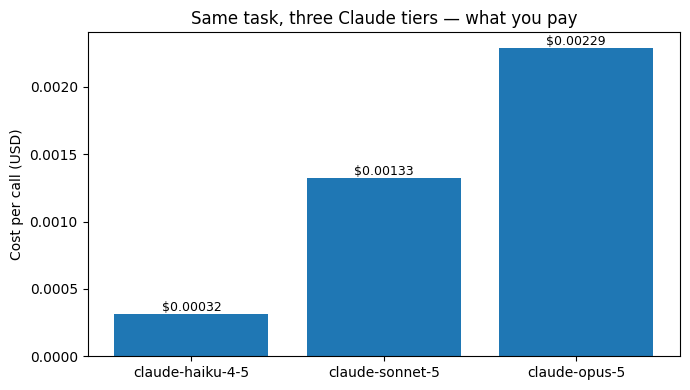

In [15]:
import matplotlib.pyplot as plt
if HAVE_KEY and results:
    runs_sorted = runs.sort_values("cost_usd")
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(runs_sorted["model"], runs_sorted["cost_usd"])
    ax.set_ylabel("Cost per call (USD)")
    ax.set_title("Same task, three Claude tiers — what you pay")
    for i, v in enumerate(runs_sorted["cost_usd"]):
        ax.text(i, v, f"${v:.5f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

In [21]:
def cost_to_read(text: str, model: str = "claude-opus-5", reads: int = 1000):
    """What does it cost for `model` to READ `text` `reads` times? (input tokens only)"""
    toks = claude_input_tokens(text, model) if HAVE_KEY else gpt_tokens(text)
    src = "Claude exact" if HAVE_KEY else "GPT approx (add a key for exact Claude)"
    price = price_row(model).in_per_1m
    total = (toks * reads / 1e6) * price
    return {"model": model, "tokens": toks, "count_source": src,
            "reads": reads, "total_usd": round(total, 4)}

cost_to_read("Paste your paragraph, prompt, or doc here.", model="claude-sonnet-5")

{'model': 'claude-sonnet-5',
 'tokens': 24,
 'count_source': 'Claude exact',
 'reads': 1000,
 'total_usd': np.float64(0.048)}

In [19]:
import urllib.request
URL = "https://www.gutenberg.org/cache/epub/1342/pg1342.txt"  # Project Gutenberg #1342
book = urllib.request.urlopen(URL).read().decode("utf-8")

words = len(book.split())
gpt_toks = gpt_tokens(book)
claude_toks = claude_input_tokens(book, "claude-sonnet-5") if HAVE_KEY else None

print("Source: Project Gutenberg #1342 (public domain)")
print(f"Words: {words:,}")
print(f"GPT-family tokens (tiktoken estimate): {gpt_toks:,}")
if HAVE_KEY:
    price_in = 2.00  # Sonnet 5 input $/1M, as of 2026-06-24 — verify current
    once = (claude_toks / 1e6) * price_in
    print(f"Claude tokens (exact, Sonnet 5): {claude_toks:,}")
    print(f"-> It costs ${once:.4f} for Claude Sonnet 5 to read all of *Pride and Prejudice* once.")
    print(f"-> Reading it 1,000 times: ${once*1000:.2f}  (input tokens only)")

Source: Project Gutenberg #1342 (public domain)
Words: 130,416
GPT-family tokens (tiktoken estimate): 175,815
Claude tokens (exact, Sonnet 5): 253,441
-> It costs $0.5069 for Claude Sonnet 5 to read all of *Pride and Prejudice* once.
-> Reading it 1,000 times: $506.88  (input tokens only)


In [23]:
def ask_with_cache(context, question, model="claude-sonnet-5"):
    t0 = time.perf_counter()
    resp = client.messages.create(
        model=model, max_tokens=200,
        system=[{"type": "text", "text": context, "cache_control": {"type": "ephemeral"}}],
        messages=[{"role": "user", "content": question}],
    )
    u = resp.usage
    return {"latency_s": round(time.perf_counter() - t0, 2),
            "input_uncached": u.input_tokens,
            "cache_write": getattr(u, "cache_creation_input_tokens", 0) or 0,
            "cache_read": getattr(u, "cache_read_input_tokens", 0) or 0,
            "output": u.output_tokens}

if HAVE_KEY:
    q = "In one sentence, what does the famous opening line claim?"
    first  = ask_with_cache(book, q)
    second = ask_with_cache(book, q)
    display(pd.DataFrame([{"call": "1st (cold)", **first}, {"call": "2nd (warm)", **second}]))

,call,latency_s,input_uncached,cache_write,cache_read,output
0,1st (cold),5.05,20,253439,0,40
1,2nd (warm),3.51,20,0,253439,41


In [25]:
if HAVE_KEY:
    IN = 2.00  # Sonnet 5 input $/1M as of 2026-06-24 — verify current
    def call_cost(r):
        return (r["input_uncached"]/1e6)*IN + (r["cache_write"]/1e6)*IN*1.25 + (r["cache_read"]/1e6)*IN*0.10
    c1, c2 = call_cost(first), call_cost(second)
    print(f"Cold read: ${c1:.4f}   Warm read: ${c2:.4f}")
    if c2: print(f"-> Cached re-read is ~{c1/c2:.0f}x cheaper on this context.")

Cold read: $0.6336   Warm read: $0.0507
-> Cached re-read is ~12x cheaper on this context.


## Write for the human\. The machine pays in tokens\.

\-Formatting isn't free\. Tables, JSON, and code cost several times more per word than prose\. Use them when they help a reader — human or model — not by reflex\.
\-Tokenizers differ\. Never price one model with another's token counts\.
\-Pick the model to the task\. The cheapest capable tier often wins; measure, don't guess\.

Your writing has a second reader now, and it reads in tokens\. Writing clearly isn't just kinder to people, it's cheaper for the machine that reads your content 60% of the time\.

Built in Deepnote\. All numbers are computed live\. Claude token counts use Anthropic's \`count\_tokens\` API; \`tiktoken\` is used only for the GPT\-family tokenizer and the concept\. Pricing is Anthropic list price as of 2026\-06\-24 — verify current before reuse\.

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=f4970cfd-dfa7-46fb-a35a-c826428b383c' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>